# Определение перспективного тарифа для телеком-компании 
В данном исследовании проведен анализ тарифов комании на выборке клиентов. Были использованы данные 500 пользователей за 2018 год. 

## Изучение общей информации и проверка форматов данных

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st

In [2]:
calls = pd.read_csv('calls.csv')
internet = pd.read_csv('internet.csv')
messages = pd.read_csv('messages.csv')
tariffs = pd.read_csv('tariffs.csv')
users = pd.read_csv('users.csv')

In [3]:
#проверяем формат данных в calls
calls.info()
calls.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202607 entries, 0 to 202606
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         202607 non-null  object 
 1   call_date  202607 non-null  object 
 2   duration   202607 non-null  float64
 3   user_id    202607 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 6.2+ MB


,id,call_date,duration,user_id
0,1000_0,2018-07-25,0.00,1000
1,1000_1,2018-08-17,0.00,1000
2,1000_2,2018-06-11,2.85,1000
3,1000_3,2018-09-21,13.80,1000
4,1000_4,2018-12-15,5.18,1000


In [4]:
#меняем формат даты в calls
calls['call_date'] = pd.to_datetime(calls['call_date'], format='%Y-%m-%d')
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202607 entries, 0 to 202606
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         202607 non-null  object        
 1   call_date  202607 non-null  datetime64[ns]
 2   duration   202607 non-null  float64       
 3   user_id    202607 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 6.2+ MB


In [5]:
#проверяем формат данных в internet
internet.info()
internet.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149396 entries, 0 to 149395
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    149396 non-null  int64  
 1   id            149396 non-null  object 
 2   mb_used       149396 non-null  float64
 3   session_date  149396 non-null  object 
 4   user_id       149396 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 5.7+ MB


,Unnamed: 0,id,mb_used,session_date,user_id
0,0,1000_0,112.95,2018-11-25,1000
1,1,1000_1,1052.81,2018-09-07,1000
2,2,1000_2,1197.26,2018-06-25,1000
3,3,1000_3,550.27,2018-08-22,1000
4,4,1000_4,302.56,2018-09-24,1000


In [6]:
#меняем формат даты в internet
internet['session_date'] = pd.to_datetime(internet['session_date'], format='%Y-%m-%d')
internet.info()

#проверяем все ли значания столбца 'Unnamed: 0' равны индексам датасета
print('Проверка столбца [Unnamed: 0]', (internet['Unnamed: 0'] - internet.index).sum())

# удаляем столбец Unnamed: 0, так как он просто дублирует индекс
internet.drop('Unnamed: 0', axis=1, inplace=True)
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149396 entries, 0 to 149395
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Unnamed: 0    149396 non-null  int64         
 1   id            149396 non-null  object        
 2   mb_used       149396 non-null  float64       
 3   session_date  149396 non-null  datetime64[ns]
 4   user_id       149396 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 5.7+ MB
Проверка столбца [Unnamed: 0] 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149396 entries, 0 to 149395
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            149396 non-null  object        
 1   mb_used       149396 non-null  float64       
 2   session_date  149396 non-null  datetime64[ns]
 3   user_id       149396 non-null  int64         
dtyp

In [7]:
#проверяем формат данных в messages
messages.info()
messages.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123036 entries, 0 to 123035
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            123036 non-null  object
 1   message_date  123036 non-null  object
 2   user_id       123036 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.8+ MB


,id,message_date,user_id
0,1000_0,2018-06-27,1000
1,1000_1,2018-10-08,1000
2,1000_2,2018-08-04,1000
3,1000_3,2018-06-16,1000
4,1000_4,2018-12-05,1000


In [8]:
#меняем формат даты в messages
messages['message_date'] = pd.to_datetime(messages['message_date'], format='%Y-%m-%d')
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123036 entries, 0 to 123035
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            123036 non-null  object        
 1   message_date  123036 non-null  datetime64[ns]
 2   user_id       123036 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 2.8+ MB


In [9]:
#проверяем формат данных в tafiffs
tariffs.info()
tariffs['gb_per_month_included'] = tariffs['mb_per_month_included']/1024
tariffs.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   messages_included      2 non-null      int64 
 1   mb_per_month_included  2 non-null      int64 
 2   minutes_included       2 non-null      int64 
 3   rub_monthly_fee        2 non-null      int64 
 4   rub_per_gb             2 non-null      int64 
 5   rub_per_message        2 non-null      int64 
 6   rub_per_minute         2 non-null      int64 
 7   tariff_name            2 non-null      object
dtypes: int64(7), object(1)
memory usage: 256.0+ bytes


,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff_name,gb_per_month_included
0,50,15360,500,550,200,3,3,smart,15.0
1,1000,30720,3000,1950,150,1,1,ultra,30.0


Добавим объем включенного в тариф трафика в гб.

In [10]:
#проверяем формат данных в users
users.info()
users.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   age         500 non-null    int64 
 2   churn_date  38 non-null     object
 3   city        500 non-null    object
 4   first_name  500 non-null    object
 5   last_name   500 non-null    object
 6   reg_date    500 non-null    object
 7   tariff      500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


In [11]:
#меняем формат даты в users
users['churn_date'] = pd.to_datetime(users['churn_date'], format='%Y-%m-%d')
users['reg_date'] = pd.to_datetime(users['reg_date'], format='%Y-%m-%d')
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   age         500 non-null    int64         
 2   churn_date  38 non-null     datetime64[ns]
 3   city        500 non-null    object        
 4   first_name  500 non-null    object        
 5   last_name   500 non-null    object        
 6   reg_date    500 non-null    datetime64[ns]
 7   tariff      500 non-null    object        
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


In [12]:
#проверка на дубликаты
print(calls.duplicated().sum())
print(internet.duplicated().sum())
print(messages.duplicated().sum())
print(tariffs.duplicated().sum())
print(users.duplicated().sum())

0
0
0
0
0


In [13]:
#проверка на пропуски данных
print(calls.isnull().sum())
print(internet.isnull().sum())
print(messages.isnull().sum())
print(tariffs.isnull().sum())
print(users.isnull().sum())

id           0
call_date    0
duration     0
user_id      0
dtype: int64
id              0
mb_used         0
session_date    0
user_id         0
dtype: int64
id              0
message_date    0
user_id         0
dtype: int64
messages_included        0
mb_per_month_included    0
minutes_included         0
rub_monthly_fee          0
rub_per_gb               0
rub_per_message          0
rub_per_minute           0
tariff_name              0
gb_per_month_included    0
dtype: int64
user_id         0
age             0
churn_date    462
city            0
first_name      0
last_name       0
reg_date        0
tariff          0
dtype: int64


Форматы столбцов с датами были приведены к формату datetime. В датасете internet был удален столбец 'Unnamed: 0'. Данный стобцец не имеет названия и просто дублирует индексы датасета.

В датафреймах нет дубликатов. Пропуски есть только в датафрейме users в столбце churn_date (по условиям проекта в данном столбце должны быть пропуски у клиентов с действующими на момент выгрузки тарифами)

## Подготовка данных (добавление рассчетных значений)

In [14]:
#количество сделанных звонков и израсходованных минут разговора по месяцам
calls['call_month'] = calls['call_date'].dt.month
calls['duration'] = np.ceil(calls['duration'])
users_calls = calls.groupby(by = ['user_id', 'call_month']).agg({'duration': ['sum', 'count']}).reset_index()
users_calls.columns = ['user_id', 'month', 'call_duration', 'call_count']
users_calls.head(5)

,user_id,month,call_duration,call_count
0,1000,5,159.0,22
1,1000,6,172.0,43
2,1000,7,340.0,47
3,1000,8,408.0,52
4,1000,9,466.0,58


In [15]:
#количество отправленных сообщений по месяцам
messages['message_month'] = messages['message_date'].dt.month
users_messages = messages.groupby(by = ['user_id', 'message_month']).agg({'id':'count'}).reset_index()
users_messages.columns = ['user_id', 'month', 'message_count']
users_messages.head(5)

,user_id,month,message_count
0,1000,5,22
1,1000,6,60
2,1000,7,75
3,1000,8,81
4,1000,9,57


In [16]:
#объем израсходованного интернет-трафика по месяцам
internet['session_month'] = internet['session_date'].dt.month
users_internet = internet.groupby(by=['user_id', 'session_month']).agg({'mb_used':'sum'}).reset_index()
users_internet['mb_used'] = np.ceil(users_internet['mb_used']/1024)
users_internet.columns = ['user_id', 'month', 'gb_used']
users_internet.head(5)

,user_id,month,gb_used
0,1000,5,3.0
1,1000,6,23.0
2,1000,7,14.0
3,1000,8,14.0
4,1000,9,15.0


In [17]:
#объединяем талбицы с расчетными значениями по каждому пользователю и по месяцам
users_stat = pd.merge(left=users_calls, right=users_messages, on=['user_id', 'month'], how='outer')
users_stat = pd.merge(left=users_stat, right=users_internet, on=['user_id', 'month'], how='outer')

#добавляем данные по клиентам и тарифам
users_stat = pd.merge(left=users_stat, right=users, on='user_id', how='left')
users_stat = pd.merge(left=users_stat, right=tariffs, left_on='tariff', right_on='tariff_name', how='left')

users_stat.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3214 entries, 0 to 3213
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                3214 non-null   int64         
 1   month                  3214 non-null   int64         
 2   call_duration          3174 non-null   float64       
 3   call_count             3174 non-null   float64       
 4   message_count          2717 non-null   float64       
 5   gb_used                3203 non-null   float64       
 6   age                    3214 non-null   int64         
 7   churn_date             187 non-null    datetime64[ns]
 8   city                   3214 non-null   object        
 9   first_name             3214 non-null   object        
 10  last_name              3214 non-null   object        
 11  reg_date               3214 non-null   datetime64[ns]
 12  tariff                 3214 non-null   object        
 13  mes

In [18]:
#рассчет помесячной выручки с каждого пользователя 

def revenue(x): #функция для расчета выручки по звонкам, сообщениям и интернету
    total = x[0]
    plan = x[1]
    price = x[2]
    if total > plan:
        revenue = (total-plan)*price
    else:
        revenue = 0
    return revenue

#расчитываем суммарную выручку по пользователям за месяц
users_stat['user_revenue'] = (
    users_stat[['call_count', 'minutes_included', 'rub_per_minute']].apply(revenue, axis=1) + 
    users_stat[['message_count', 'messages_included', 'rub_per_message']].apply(revenue, axis=1) + 
    np.ceil(users_stat[['gb_used','gb_per_month_included', 'rub_per_gb']]).apply(revenue, axis=1) +
    users_stat['rub_monthly_fee']
)

users_stat.head(5)

,user_id,month,call_duration,call_count,message_count,gb_used,age,churn_date,city,first_name,...,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff_name,gb_per_month_included,user_revenue
0,1000,5,159.0,22.0,22.0,3.0,52,NaT,Краснодар,Рафаил,...,1000,30720,3000,1950,150,1,1,ultra,30.0,1950.0
1,1000,6,172.0,43.0,60.0,23.0,52,NaT,Краснодар,Рафаил,...,1000,30720,3000,1950,150,1,1,ultra,30.0,1950.0
2,1000,7,340.0,47.0,75.0,14.0,52,NaT,Краснодар,Рафаил,...,1000,30720,3000,1950,150,1,1,ultra,30.0,1950.0
3,1000,8,408.0,52.0,81.0,14.0,52,NaT,Краснодар,Рафаил,...,1000,30720,3000,1950,150,1,1,ultra,30.0,1950.0
4,1000,9,466.0,58.0,57.0,15.0,52,NaT,Краснодар,Рафаил,...,1000,30720,3000,1950,150,1,1,ultra,30.0,1950.0


## Анализ данных

In [19]:
#Рассчет средних значений количества минут разговора, количества сообщений и объёма интернет-трафика 
#на одного пользователя по тарифам
users_stat = users_stat.fillna(0)
group_users_stat = users_stat.groupby(by='tariff_name')[['call_duration', 'message_count', 'gb_used']].mean()
group_users_stat

,call_duration,message_count,gb_used
tariff_name,,,
smart,417.934948,33.384029,16.328847
ultra,526.623350,49.363452,19.494416


In [20]:
#дисперсия и стандарное отклонение количества минут разговора тариф Ультра
var_call_ultra = np.var(users_stat.query('tariff_name == "ultra"')['call_duration'], ddof=1)
std_call_ultra = np.std(users_stat.query('tariff_name == "ultra"')['call_duration'], ddof=1)

#дисперсия и стандарное отклонение количества минут разговора тариф Смарт
var_call_smart = np.var(users_stat.query('tariff_name == "smart"')['call_duration'], ddof=1)
std_call_smart = np.std(users_stat.query('tariff_name == "smart"')['call_duration'], ddof=1)

group_users_stat['var_call'] = [var_call_smart, var_call_ultra]
group_users_stat['std_call'] = [std_call_smart, std_call_ultra]
group_users_stat

,call_duration,message_count,gb_used,var_call,std_call
tariff_name,,,,,
smart,417.934948,33.384029,16.328847,36219.315784,190.313730
ultra,526.623350,49.363452,19.494416,100873.633397,317.606098


In [21]:
#дисперсия и стандарное отклонение количества сообщений тарифа Ультра
var_mess_ultra = np.var(users_stat.query('tariff_name == "ultra"')['message_count'], ddof=1)
std_mess_ultra = np.std(users_stat.query('tariff_name == "ultra"')['message_count'], ddof=1)

#дисперсия и стандарное отклонение количества сообщений тариф Смарт
var_mess_smart = np.var(users_stat.query('tariff_name == "smart"')['message_count'], ddof=1)
std_mess_smart = np.std(users_stat.query('tariff_name == "smart"')['message_count'], ddof=1)

group_users_stat['var_mess'] = [var_mess_smart, var_mess_ultra]
group_users_stat['std_mess'] = [std_mess_smart, std_mess_ultra]
group_users_stat

,call_duration,message_count,gb_used,var_call,std_call,var_mess,std_mess
tariff_name,,,,,,,
smart,417.934948,33.384029,16.328847,36219.315784,190.313730,796.812958,28.227876
ultra,526.623350,49.363452,19.494416,100873.633397,317.606098,2285.266143,47.804457


In [22]:
#дисперсия и стандарное отклонение объёма интернет-трафика тарифа Ультра
var_gb_ultra = np.var(users_stat.query('tariff_name == "ultra"')['gb_used'], ddof=1)
std_gb_ultra = np.std(users_stat.query('tariff_name == "ultra"')['gb_used'], ddof=1)

#дисперсия и стандарное отклонение объёма интернет-трафика тариф Смарт
var_gb_smart = np.var(users_stat.query('tariff_name == "smart"')['gb_used'], ddof=1)
std_gb_smart = np.std(users_stat.query('tariff_name == "smart"')['gb_used'], ddof=1)

group_users_stat['var_gb'] = [var_gb_smart, var_gb_ultra]
group_users_stat['std_gb'] = [std_gb_smart, std_gb_ultra]
display(group_users_stat.round(2))
print('Превышение значений по тарифу Ultra')
display(group_users_stat.iloc[1].div(group_users_stat.iloc[0]).round(2))

,call_duration,message_count,gb_used,var_call,std_call,var_mess,std_mess,var_gb,std_gb
tariff_name,,,,,,,,,
smart,417.93,33.38,16.33,36219.32,190.31,796.81,28.23,33.03,5.75
ultra,526.62,49.36,19.49,100873.63,317.61,2285.27,47.80,97.09,9.85


Превышение значений по тарифу Ultra


call_duration    1.26
message_count    1.48
gb_used          1.19
var_call         2.79
std_call         1.67
var_mess         2.87
std_mess         1.69
var_gb           2.94
std_gb           1.71
dtype: float64

Поведение клиентов отличается в зависимости от используемого тарифа. Клиенты с тарифам  Ultra более активно пользуются услугами компании. Они совершают более длительные звонки (в 1.26 раза), отправляют больше сообщений (в 1.48 раза) и расходуют больше интернет-трафика (в 1.19 раза). 

Дисперсия и страндартное отклонение по анализируемым показателям существенно больше по тарифу Ultra. Это значит, что разброс значений показателей для данного тарифа больше.

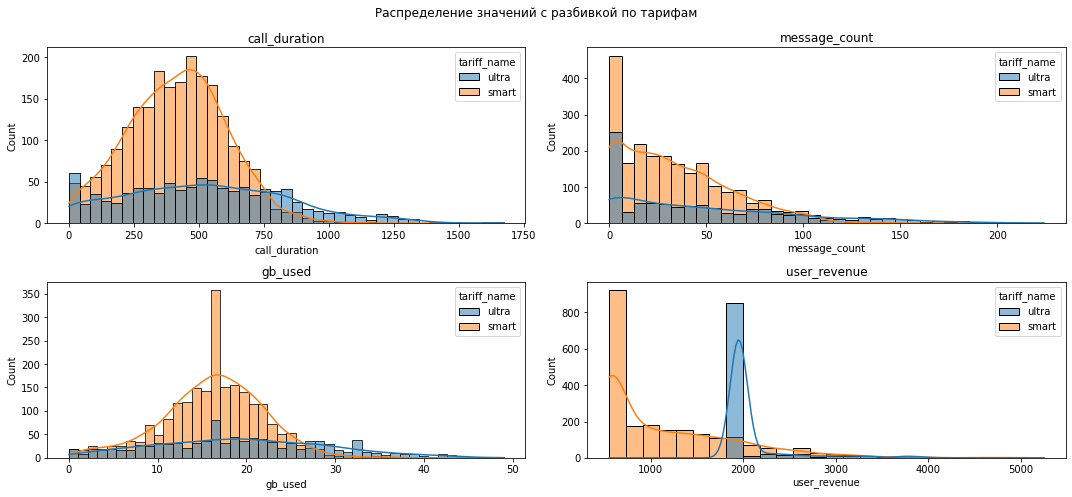

In [23]:
#гисторграммы распределения
param = ['call_duration', 'message_count', 'gb_used', 'user_revenue']

plt.figure(figsize = (15, 7))

for i, param in enumerate(param):
    sns.histplot(users_stat, x=param, kde=True, hue = 'tariff_name', ax = plt.subplot(2, 2, i+1))
    plt.title(param)

plt.suptitle('Распределение значений с разбивкой по тарифам')
plt.tight_layout()

Распределение длительности звонков за месяц на форме близко к нормальному для обоим тарифам. По тарифу Smart распределение имеет отрицательную скошенность. Стандартное отклонение по тарифу Ultra также больше, чем по тарифу Smart в 1.67 раза. 

Распределение объемов расходуемого трафика на форме близко к нормальному для обоим тарифам. При этом стандартное отклонение по тарифу Ultra больше, чем по тарифу Smart в 1.71 раза. 
 
Распределение  количества сообщений имеет положительную скошенность по обоим тарифам. Стандартное отклонение по тарифу Ultra также больше, чем по тарифу Smart в 1.69 раза. 

Форма распределения выручки по тарифам объсняется тем, что большинство пользователей не превышают лимиты услуг по тарифам и платят только базовую стоимость. При этом по тарифу Smart больше клиентов, превышающих лимиты по услугам. По тарифу Ultra практически все клиенты платят только базовую стоимость.

## Проверка гипотез

In [24]:
#Проверка гипотезы "средняя выручка пользователей тарифов «Ультра» и «Смарт» различается"

alpha = .01

results = st.ttest_ind(
    users_stat.query('tariff_name == "ultra"')['user_revenue'], 
    users_stat.query('tariff_name == "smart"')['user_revenue'])

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print("Cредняя выручка пользователей тарифов Ultra и Smart различается")
else:
    print("Средняя выручка пользователей тарифов Ultra и Smart не различается") 

print('Средняя выручка по тарифу Ultra', users_stat.query('tariff_name == "ultra"')['user_revenue'].mean().round())
print('Средняя выручка по тарифу Smart',  users_stat.query('tariff_name == "smart"')['user_revenue'].mean().round())

p-значение: 1.7908299298705238e-242
Cредняя выручка пользователей тарифов Ultra и Smart различается
Средняя выручка по тарифу Ultra 2070.0
Средняя выручка по тарифу Smart 1165.0


Исходя из постановки задачи, нам нужно проверить гипотезу о равенстве средних двух генеральных совокупностей, поэтому нужно использовать метод scipy.stats.ttest_ind (array1, array2, equal_var).
Нулевая гипотеза - средняя выручка для тарифов Ultra и Smart равна. Альтернативная гипотеза - средняя выручка пользователей тарифов Ultra и Smart различается.
Нулевая гипотеза отпровергнута. Так как средняя выборочная выручка по тарифу Ultra больше, чем по тарифу Smart, то можно уточнить альтернативную теорию - средняя выручка пользователей по тарифу Ultra больше, чем по тарифу Smart.

In [25]:
#Проверка гипотезы "средняя выручка пользователей из Москвы отличается от выручки пользователей из других регионов" 
alpha = .01

results = st.ttest_ind(
    users_stat.query('city == "Москва"')['user_revenue'], 
    users_stat.query('city != "Москва"')['user_revenue'])

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print("Cредняя выручка пользователей из Москвы отличается от выручки пользователей из других регионов")
else:
    print("Cредняя выручка пользователей из Москвы и других регионов не отличаются") 

print('Средняя выручка по Москву', users_stat.query('city == "Москва"')['user_revenue'].mean().round())
print('Средняя выручка по другим регионам',  users_stat.query('city != "Москва"')['user_revenue'].mean().round())


p-значение: 0.2959013162901812
Cредняя выручка пользователей из Москвы и других регионов не отличаются
Средняя выручка по Москву 1472.0
Средняя выручка по другим регионам 1436.0


Нулевая гипотеза - средняя выручка пользователей из Москвы и других регионов не отличаются. Альтернативная - средняя выручка пользователей из Москвы отличается от выручки пользователей из других регионов. 
Нулевая гипотеза не отпровергнута.

## Общий вывод

Наиболее доходным для компании является тариф Ultra. 

Клиенты с данным тарифом более активно пользуются услугами компании и платят более высокую абонентскую плату. Они совершают более длительные звонки (в 1.26 раза), отправляют больше сообщений (в 1.48 раза), расходуют больше интернет-трафика (в 1.19 раза) и приносят компании больше дохода в 1.78 раза. 


Также исходя из данных выборки можно сделать вывод о том, что размер средней выручки по одному клиенту в месяц не зависит от региона нахождения клиента. 

Большинство пользователей компании не превышают лимиты услуг по тарифам и платят только базовую стоимость. При этом по тарифу Smart больше клиентов, превышающих лимиты по услугам, чем по тарифу Ultra. По тарифу Ultra практически все клиенты платят только базовую стоимость. 